# Figure 3: True-Colour Film Strip (4×4 panel)

**Rows** = storms: Ragasa (2025), Mangkhut (2018), Maria (2017), Dorian (2019)  
**Cols** = T−48 h, T_peak, T_closest, T+24 h  

Source: GIBS / NASA Worldview MODIS Terra Corrected Reflectance.  
Grey tiles = nighttime or unavailable (placeholder).  

**Prerequisite**: `data/gibs/{storm}/tc_*.png` (run `04_download_gibs.py` first).

## 1: Setup

In [7]:
import os, sys, glob
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))
from utils import GIBS_DIR, FIG_DIR, STORM_ORDER, STORMS, ensure_dirs

ensure_dirs()
OUTPATH    = os.path.join(FIG_DIR, 'truecolor_filmstrip.png')
COL_LABELS = ['T−48 h', 'T_peak', 'T_closest\n(impact ref)', 'T+24 h']
DATE_KEYS  = ['t_minus48_date', 't_peak_date', 't_closest_date', 't_plus24_date']
LABEL_TAGS = ['T-48h', 'T_peak', 'T_closest', 'T+24h']

## 2: Helper: load tile (grey placeholder if missing)

In [8]:
def load_tile(storm_key, label_tag, date_str):
    pattern = os.path.join(GIBS_DIR, storm_key, f'tc_{label_tag}_{date_str}.png')
    matches = glob.glob(pattern)
    if not matches:
        # Try any tc_ file for this label (date string may differ slightly)
        matches = glob.glob(os.path.join(GIBS_DIR, storm_key, f'tc_{label_tag}_*.png'))
    if not matches:
        return np.full((512, 512, 3), 70, dtype=np.uint8)
    try:
        return np.array(Image.open(matches[0]).convert('RGB'))
    except Exception:
        return np.full((512, 512, 3), 70, dtype=np.uint8)


# Preview: check which tiles exist
for key in STORM_ORDER:
    tiles = glob.glob(os.path.join(GIBS_DIR, key, 'tc_*.png'))
    print(f'{key}: {len(tiles)} true-colour tiles')

ragasa: 4 true-colour tiles
mangkhut: 4 true-colour tiles
maria: 4 true-colour tiles
dorian: 4 true-colour tiles


## 3: Assemble and save

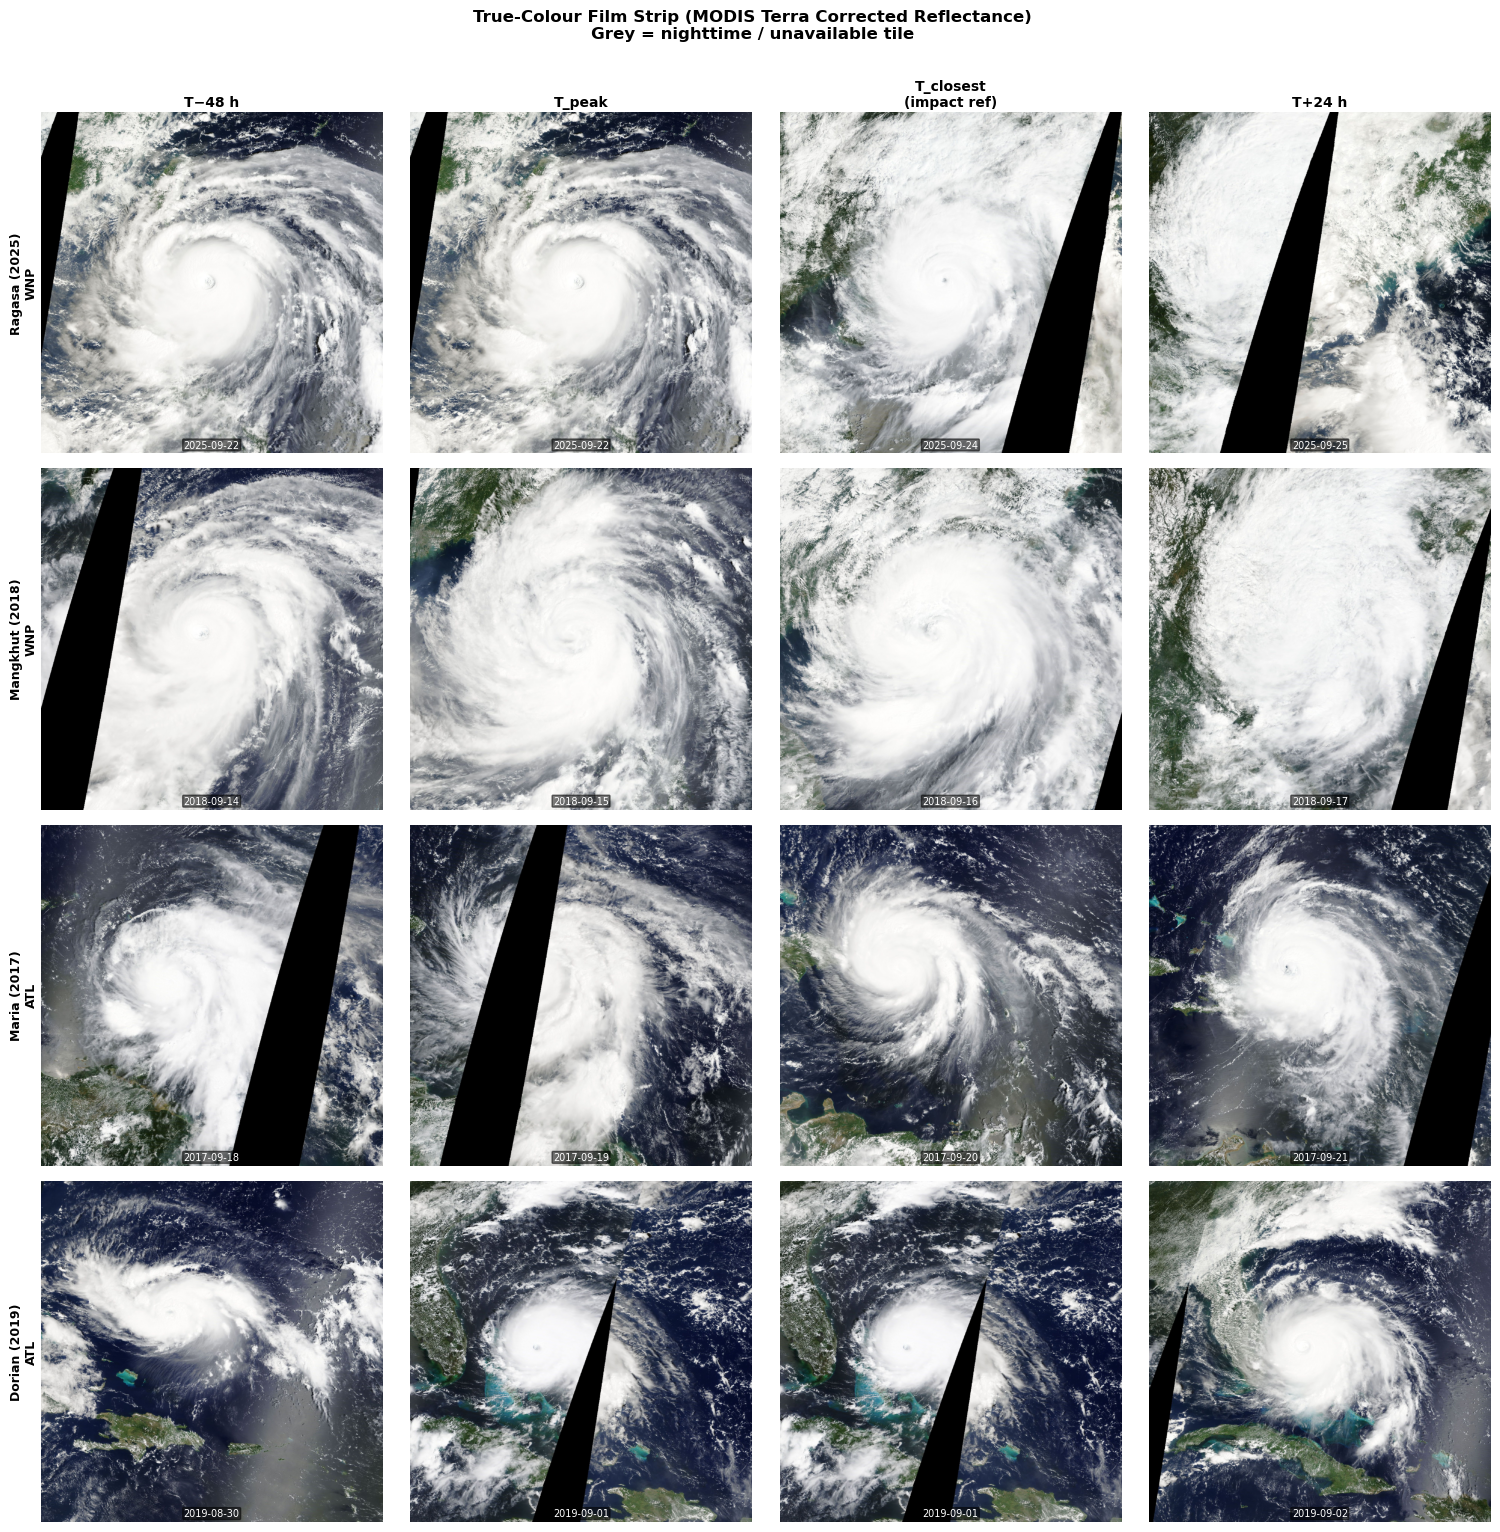

Saved → /home/sharperace/geog_1.02_final_proj/figures/truecolor_filmstrip.png


In [9]:
n_rows, n_cols = len(STORM_ORDER), len(COL_LABELS)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3.8, n_rows * 3.8))

for r, key in enumerate(STORM_ORDER):
    meta = STORMS[key]
    for c, (label_tag, date_key, col_lbl) in enumerate(
            zip(LABEL_TAGS, DATE_KEYS, COL_LABELS)):

        ax       = axes[r][c]
        date_str = meta[date_key]
        arr      = load_tile(key, label_tag, date_str)

        ax.imshow(arr)
        ax.axis('off')

        if r == 0:
            ax.set_title(col_lbl, fontsize=10, fontweight='bold', pad=4)

        ax.text(0.5, 0.01, date_str, transform=ax.transAxes,
                ha='center', va='bottom', fontsize=7, color='white',
                bbox=dict(boxstyle='round,pad=0.1', fc='k', alpha=0.5))

    # Row label on the left (set_ylabel is suppressed by axis('off'), use text instead)
    axes[r][0].text(
        -0.05, 0.5,
        f"{meta['name']} ({meta['year']})\n{meta['basin']}",
        transform=axes[r][0].transAxes,
        fontsize=9, fontweight='bold',
        rotation=90, ha='center', va='center'
    )

fig.suptitle(
    'True-Colour Film Strip (MODIS Terra Corrected Reflectance)\n'
    'Grey = nighttime / unavailable tile',
    fontsize=12, fontweight='bold', y=1.005
)
plt.tight_layout()
plt.savefig(OUTPATH, dpi=180, bbox_inches='tight')
plt.show()
print(f'Saved → {OUTPATH}')
